# 18. Circle Packing: The Portrait in Dots

One rule, *circles must not overlap*, turns random scatter into organic density. Today we pack a canvas by refusal and then by growth, hand the radius budget to a painting's light, and rebuild chapter 6's Monet as a shimmering field of thousands of circles.

## Today's destination

Monet's water lilies, reassembled from more than seven thousand circles that may kiss but never overlap. The pond's dark passages are ground into the finest grain, the lily pads breathe in larger coins, and every circle wears the color the painting keeps beneath its center. Not one circle was placed by hand; each one was *offered* to the canvas at random, and the canvas refused or accepted it. By the end of today you can pack circles into any image, or into pure emptiness, and you will know why the humble word *no* is one of composition's strongest tools.

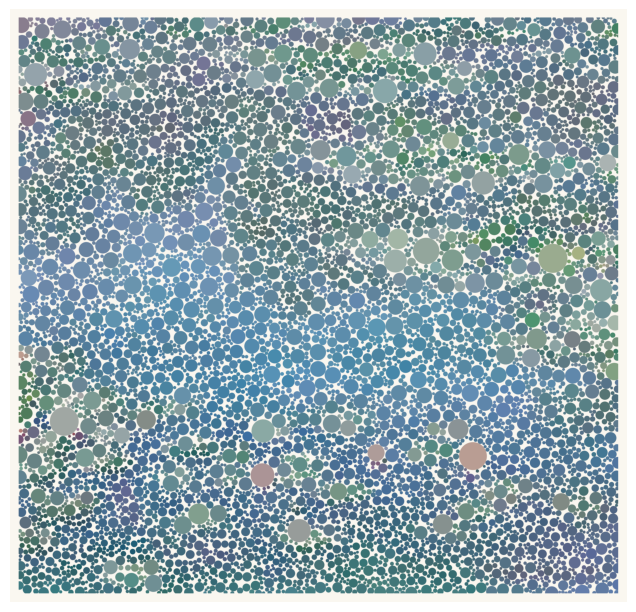

In [1]:
# display this chapter's showpiece (generated by the last cell of this notebook)
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

showpiece_path = "../assets/outputs/ch18_showpiece.png"
if os.path.exists(showpiece_path):
    image = mpimg.imread(showpiece_path)
    plt.figure(figsize=(8, 7.7))
    plt.imshow(image)
    plt.axis("off")
    plt.show()
else:
    print("Not generated yet -- run the whole notebook once and come back.")

## Context: the circle as compositional atom

Among shapes, the circle is the one with no direction, no corner, no top: the mark that is pure *presence*. Painters of abstraction reached for it early. Kandinsky's *Farbstudie: Quadrate mit konzentrischen Ringen* (Color Study: Squares with Concentric Rings, 1913; Städtische Galerie im Lenbachhaus, Munich) is not a finished painting but a small working study in watercolor, gouache and crayon, twelve nests of colored rings in a grid of squares <a class="cite" href="#ref-lenbachhaus">(Lenbachhaus, collection entry)</a>; the German title says rings, not circles, and either way it has become a much-reproduced image. Half a century later and an ocean away, **Yayoi Kusama** made the dot an obsession: in late-1950s New York she began covering enormous canvases with thousands of tiny painted loops, the *Infinity Nets*, a compulsive space-filling she traces to childhood hallucinations of proliferating dots. In her autobiography *Infinity Net* (2002; English translation 2011) she names the endpoint of the process 'self-obliteration': the self dissolving into an endless field of dots <a class="cite" href="#ref-kusama2011">(Kusama 2011)</a>.

**Damien Hirst**'s spot paintings make a useful counter-example. The gridded ones, the Pharmaceutical Paintings (the series begins in 1986, and most are executed by assistants), follow strict rules: uniform circles on a regular grid, evenly spaced, never touching, and, by Hirst's own rule, no color repeated within a painting <a class="cite" href="#ref-hirst">(Damien Hirst studio, series text)</a>. Note carefully: a grid is *not* a packing. Hirst's spots are **placed**; today's circles will be **fitted**, each one negotiating its size against every neighbor. That difference, allocation versus negotiation, is the entire lesson, and your eye can tell the two apart at twenty paces.

The mathematics of fitted circles is old. Apollonius of Perga (c. 262 to c. 190 BC) asked, in a treatise now lost, how to construct a circle tangent to three given ones (<a class="cite" href="#ref-heath1921">Heath 1921</a>; <a class="cite" href="#ref-coxeter1968">Coxeter 1968</a>); Descartes stated the curvature relation for four mutually touching circles in a 1643 letter to Princess Elisabeth of Bohemia; in 1936 the chemist Frederick Soddy rediscovered that relation and published it in *Nature* as a poem, "The Kiss Precise" <a class="cite" href="#ref-soddy1936">(Soddy 1936)</a>. Fill the gaps between touching circles with ever smaller touching circles, forever, and you get the **Apollonian gasket**, self-similarity made of circles (chapter 8 trained your eye for exactly this), though the fractal packing itself is a modern construction that merely borrows Apollonius's name.

And the painterly stakes are familiar ones: chapter 15 rebuilt a Vermeer from *points*; today's marks have **area**, so they must negotiate for room. As with Seurat's divisionism, the image is built from small separate touches of color meant to fuse in the viewer's eye. Circle packing (Kreispackung) remains a staple of contemporary generative practice, from long-form browser works to pen-plotter prints, precisely because so simple a rule yields such organic density <a class="cite" href="#ref-hobbs2016">(Hobbs 2016)</a>.

## The collision test

Everything in this chapter rests on one line of geometry. Two circles with centers $c_1, c_2$ and radii $r_1, r_2$ **overlap** exactly when the distance between their centers is smaller than the sum of their radii:

$$d(c_1, c_2) \; < \; r_1 + r_2$$

Equality is the tender boundary case: the circles *kiss*, touching at a single point (Soddy chose his poem's title well). Anything larger and daylight shows between them. That is the whole theory; the rest of the chapter is about *offering* circles to a canvas and letting this test say no.

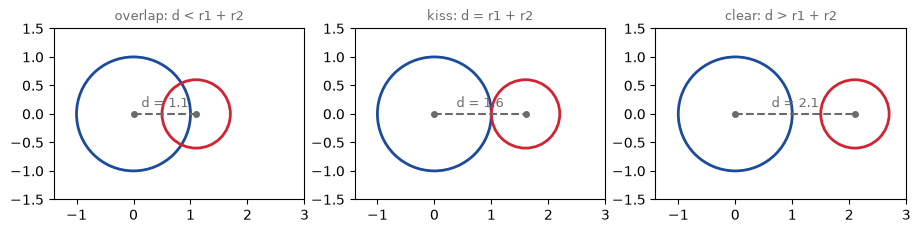

In [2]:
# the collision test, seen: the same two circles at three distances
# (plt.Circle + add_patch: chapter 2's Rectangle recipe, with a round patch)
import numpy as np

r_1, r_2 = 1.0, 0.6
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
for ax, d, verdict in zip(axes, [1.1, 1.6, 2.1],
                          ["overlap: d < r1 + r2", "kiss: d = r1 + r2",
                           "clear: d > r1 + r2"]):
    ax.add_patch(plt.Circle((0, 0), r_1, fill=False, color="#1B4B9B", linewidth=2))
    ax.add_patch(plt.Circle((d, 0), r_2, fill=False, color="#D02433", linewidth=2))
    ax.plot([0, d], [0, 0], "o--", color="#6B6B6B", markersize=4)
    ax.text(d / 2, 0.12, f"d = {d}", ha="center", fontsize=9, color="#6B6B6B")
    ax.set_xlim(-1.4, 3.0)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect("equal")
    ax.set_title(verdict, fontsize=9, color="#6B6B6B")
plt.show()

## Packing by refusal

How do you *fill* a canvas with non-overlapping circles? The first honest idea is chapter 15's rejection sampling, wearing armor: propose a random center, and **refuse** it if a circle of the wanted size would overlap anything already placed. (Chapter 15 refused points by a probability; today the veto is geometric and absolute.) We try it with equal circles and, importantly, we keep the *receipts*: for every circle that lands, we record how many proposals it cost. Chapter 2's seeded `rng` makes the whole experiment repeatable.

One numpy habit before the loop. All the placed centers sit in a plain Python list that grows with `.append`; the moment we need geometry we wrap it in `np.array` and measure every distance at once with `np.linalg.norm` (chapter 15 glossed it: the length of each gap vector). List for growing, array for math: you will see this list-then-array rhythm in both engines today.

In [3]:
# naive packing: equal circles, placed by pure stubborn refusal
def pack_rejection(rng, width, height, radius, tries):
    centers = []                # grows as a list; wrapped in np.array for math
    costs = []                  # proposals each accepted circle cost us
    attempts = 0
    for proposal in range(tries):
        attempts += 1
        x, y = rng.uniform(0, width), rng.uniform(0, height)
        if centers:
            gaps = np.linalg.norm(np.array(centers) - [x, y], axis=1)
            if gaps.min() < 2 * radius:     # overlap exactly when d < r + r: refuse
                continue
        centers.append([x, y])
        costs.append(attempts)
        attempts = 0
    return np.array(centers), np.array(costs)

rng = np.random.default_rng(2)
eq_centers, eq_costs = pack_rejection(rng, 300, 300, radius=9, tries=20000)
print(f"{len(eq_centers)} circles landed, {20000} proposals spent")

193 circles landed, 20000 proposals spent


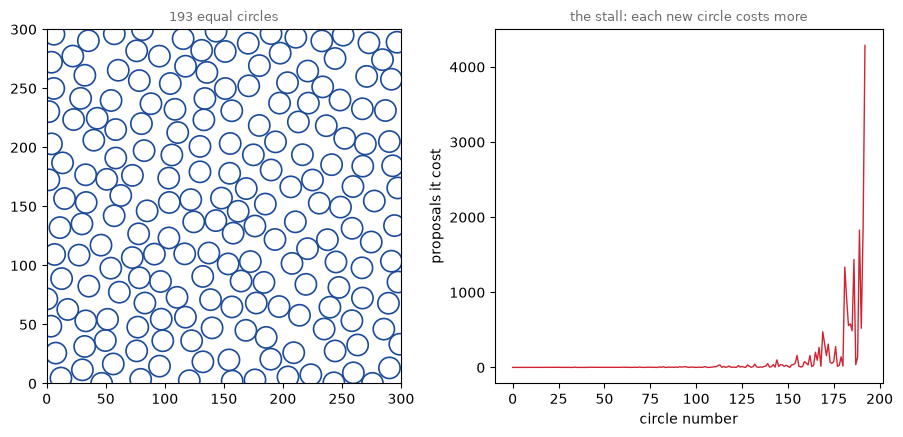

In [4]:
# the pack, and the price of every circle in it
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for x, y in eq_centers:
    axes[0].add_patch(plt.Circle((x, y), 9, fill=False, color="#1B4B9B",
                                 linewidth=1.2))
axes[0].set_xlim(0, 300)
axes[0].set_ylim(0, 300)
axes[0].set_aspect("equal")
axes[0].set_title(f"{len(eq_centers)} equal circles", fontsize=9, color="#6B6B6B")
axes[1].plot(eq_costs, color="#D02433", linewidth=1)
axes[1].set_xlabel("circle number")
axes[1].set_ylabel("proposals it cost")
axes[1].set_title("the stall: each new circle costs more", fontsize=9,
                  color="#6B6B6B")
plt.show()

**Look and compare.** The first circles cost one or two proposals each; the last ones cost hundreds or thousands, and the curve is still climbing when the budget runs out. The reason is visible on the left: the *free* area shrinks toward awkward slivers no fixed-size circle fits into, so almost every proposal lands on a refusal. Pure rejection packing stalls, and no budget outruns it: this is our negative control, chapter 10's TV-static moment for packing.

**Try it.** Rerun the two cells with `radius=5`. More circles land, but watch the cost curve: the stall arrives all the same, only later.

## Packing by growth

The cure is to stop insisting on a size. **Drop small, grow until touch, keep**: propose a center, and if even a tiny circle fits there, let it inflate until it kisses its nearest neighbor (or hits a size limit), then freeze it. Every sliver of leftover space is now a home for *something*, so the canvas fills with a natural hierarchy: big founders early, generations of ever finer grain in the gaps. Two tools follow, and the pictures right after: the engine (which also accepts a map setting the size limit per location; a painting will play that map shortly) and a renderer we reuse all chapter. This greedy growth is the standard packing move in generative art <a class="cite" href="#ref-hobbs2016">(Hobbs 2016)</a>, and it needs one more observation to be fast: a growing circle always stops at the nearest circle-edge, so instead of inflating in tiny steps we can *jump* straight to the gap. (The step-by-step version survives as a `step` argument, and it is not useless: quantized radii have a look of their own, as the parameter studies will show.)

In [5]:
# growth packing: drop small, grow until touch, keep
def pack_growth(rng, width, height, min_r=1.0, max_r=30, tries=20000,
                cap_map=None, step=None):
    xs, ys, radii = [], [], []    # flat lists while growing, arrays for math
    for proposal in range(tries):
        x, y = rng.uniform(0, width), rng.uniform(0, height)
        # the local size limit: one number, or looked up in a map (soon: a painting)
        cap = max_r if cap_map is None else cap_map[int(y), int(x)]
        room = cap
        if xs:
            # distance to every placed circle's EDGE at once: chapter 15's
            # sqrt of squared differences, vectorized over the whole pack
            distances = np.sqrt((np.array(xs) - x)**2 + (np.array(ys) - y)**2)
            room = min(cap, (distances - np.array(radii)).min())
        if room < min_r:
            continue              # no room for even the smallest circle: refuse
        if step is None:
            r = room              # grow until touch, jumped in one line
        else:
            r = min_r             # or grow in audible clicks of size `step`
            while r + step <= room:
                r += step
        xs.append(x)
        ys.append(y)
        radii.append(r)
    return np.stack([xs, ys], axis=1), np.array(radii)

In [6]:
# a renderer we will reuse all chapter (ax= follows chapter 6's panel pattern)
import sys
sys.path.append("..")
from agap.helpers import PAPER, save_artwork

def draw_pack(centers, radii, colors, width, height, rings=0, ax=None, figsize=9):
    if ax is None:
        fig, ax = plt.subplots(figsize=(figsize, figsize * height / width))
    else:
        fig = ax.figure
    fig.patch.set_facecolor(PAPER)
    ax.set_facecolor(PAPER)
    if isinstance(colors, str):             # one ink for all, or one color each
        colors = [colors] * len(radii)
    for (x, y), r, color in zip(centers, radii, colors):
        if rings == 0:                      # filled circle (Rectangle's cousin, ch2)
            ax.add_patch(plt.Circle((x, y), r, color=color, linewidth=0))
        else:                               # outlines, not fills (the Kandinsky variant, later)
            for ring_r in np.linspace(r, r * 0.25, rings):
                ax.add_patch(plt.Circle((x, y), ring_r, fill=False,
                                        edgecolor=color, linewidth=0.7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)                  # image convention: y grows downward
    ax.set_aspect("equal")
    ax.axis("off")
    return fig

1643 circles, radius 1.0 to 45.0


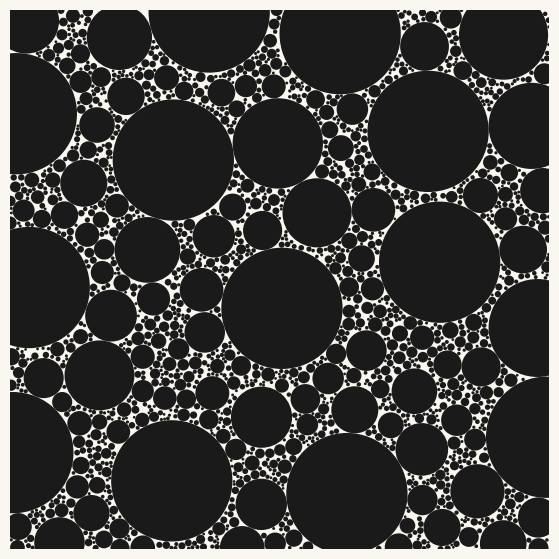

In [7]:
# growth packing on a blank canvas: watch the hierarchy of generations
rng = np.random.default_rng(7)
blank_centers, blank_radii = pack_growth(rng, 400, 400, min_r=1.0, max_r=45,
                                         tries=40000)
print(f"{len(blank_radii)} circles, radius {blank_radii.min():.1f} "
      f"to {blank_radii.max():.1f}")
art_blank = draw_pack(blank_centers, blank_radii, "#1A1A1A", 400, 400, figsize=7)
plt.show()

No stall this time: where rejection packing left slivers, growth packing mints coins of exactly the sliver's size. The texture is the negotiation made visible: every circle is precisely as large as its neighbors allowed it to be.

**Try it.** Set `min_r=0.4` and the count explodes into sand; set `min_r=6` and the pack goes back to being coarse and gappy, halfway to the rejection version. The minimum radius is the *patience* of the packing.

## A radius budget from the painting

So far the size limit `max_r` was one number everywhere. The `cap_map` argument lets a **picture** set the limit instead: at every proposal, the engine looks up how large a circle may grow *right here*. Feed it a painting's brightness and the packing becomes a portrait: bright passages afford large circles, dark passages only the finest grain, which is chapter 15's ink logic (dark buys detail) speaking the language of area. We take chapter 6's Monet, recurring in this book like a motif, and prepare its budget with one adjustment you already know from chapter 15's engraver (a gamma to steer how fast size falls off with darkness) and one new one: stretching the tones so the budget uses the painting's full range. A light blur (scipy's `gaussian_filter`, first met in chapter 17's showpiece) steadies the map so single bright pixels cannot buy giant circles.

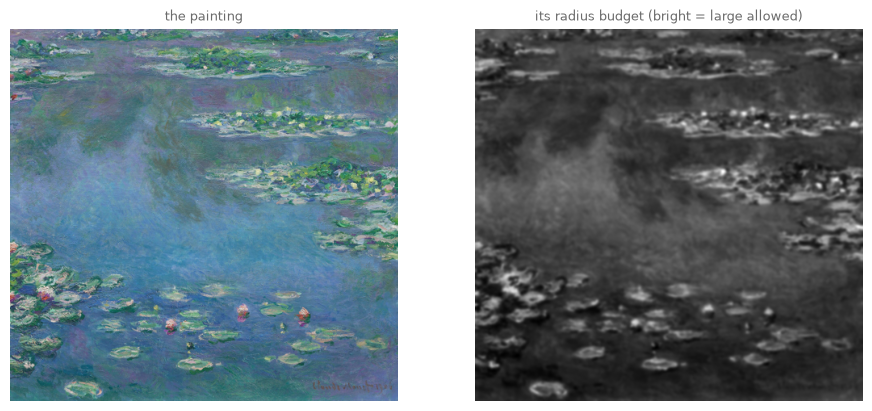

In [8]:
# chapter 6's Monet becomes a radius budget
from PIL import Image
from scipy.ndimage import gaussian_filter

original = Image.open("../assets/images/monet_waterlilies.jpg")
scale_w = 480
scale_h = int(original.height * scale_w / original.width)
gray = np.asarray(original.convert("L").resize((scale_w, scale_h))) / 255
color = np.asarray(original.convert("RGB").resize((scale_w, scale_h))) / 255

stretched = (gray - gray.min()) / (gray.max() - gray.min())   # use the full range
smooth_light = gaussian_filter(stretched, 1.5)
cap_map = 1.1 + smooth_light**1.8 * (22 - 1.1)   # stretches 0..1 into the 1.1..22 px range; the blur pulls both inward

fig, axes = plt.subplots(1, 2, figsize=(11, 5.4))
axes[0].imshow(color)
axes[0].set_title("the painting", fontsize=9, color="#6B6B6B")
axes[1].imshow(cap_map, cmap="gray")
axes[1].set_title("its radius budget (bright = large allowed)", fontsize=9,
                  color="#6B6B6B")
for ax in axes:
    ax.axis("off")
plt.show()

6603 circles accepted


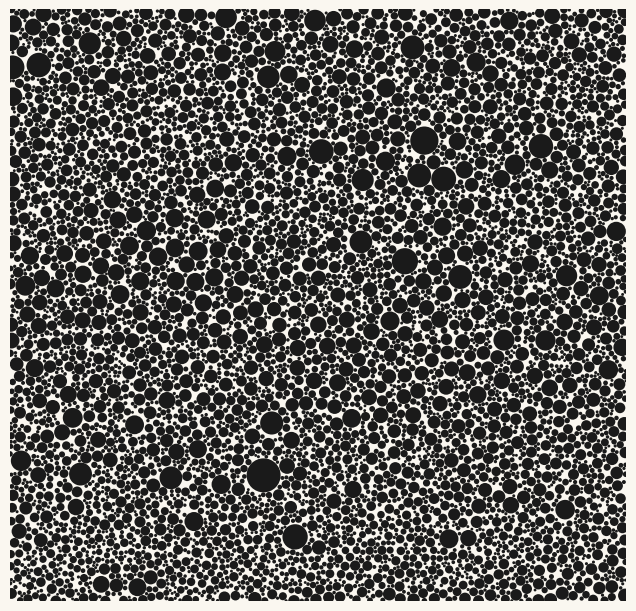

In [9]:
# pack the pond: sixty thousand proposals against the budget (about 20 s)
rng = np.random.default_rng(14)
centers, radii = pack_growth(rng, scale_w, scale_h, min_r=1.1, max_r=22,
                             tries=60000, cap_map=cap_map)
print(f"{len(radii)} circles accepted")
art_ink = draw_pack(centers, radii, "#1A1A1A", scale_w, scale_h, figsize=8)
plt.show()

In ink alone the painting is only half there: packing density is roughly even everywhere, so what carries the image is the *grain*, fine where the pond is dark, coarse where the lilies catch light. Squint and the composition surfaces. To make it unmistakable we add chapter 15's exercise idea, now promoted to the canonical move: **each circle samples the painting's color at its own center**. One refinement travels along from chapter 17's showpiece: we sample a lightly blurred copy of the painting, so a circle speaks for its neighborhood rather than for one stray bright pixel of brushwork.

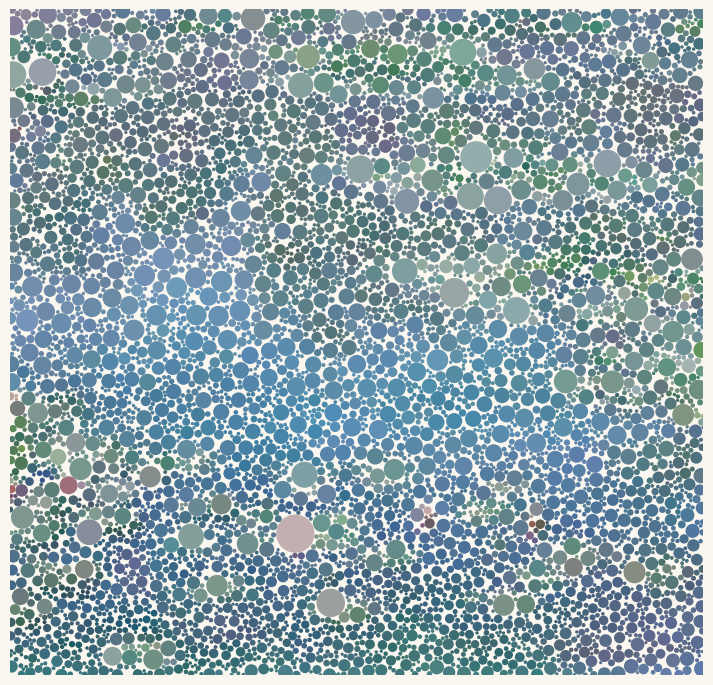

In [10]:
# the payoff: every circle wears its center's color (sampled from a blurred copy)
smooth_color = color.copy()
for channel in range(3):
    smooth_color[..., channel] = gaussian_filter(color[..., channel], 2.0)

# two index arrays pick one pixel per circle (chapter 15's indexing idiom)
circle_colors = smooth_color[centers[:, 1].astype(int), centers[:, 0].astype(int)]

art_color = draw_pack(centers, radii, circle_colors, scale_w, scale_h, figsize=9)
plt.show()

There is the pond: not one line drawn, and yet water, lilies and reflected sky sort themselves out, because color and grain now agree about where things are. As with Seurat, the touches are meant to fuse at viewing distance; lean back from the screen and watch it happen.

## The Kandinsky variant: rings instead of fills

The renderer's `rings` argument replaces every fill with a nest of concentric outlines, a quiet bow to the 1913 color study. The result is also, not by accident, a drawing made of nothing but strokes: chapter 26 will take exactly this discipline (lines only, no fills) all the way to a pen plotter's paper.

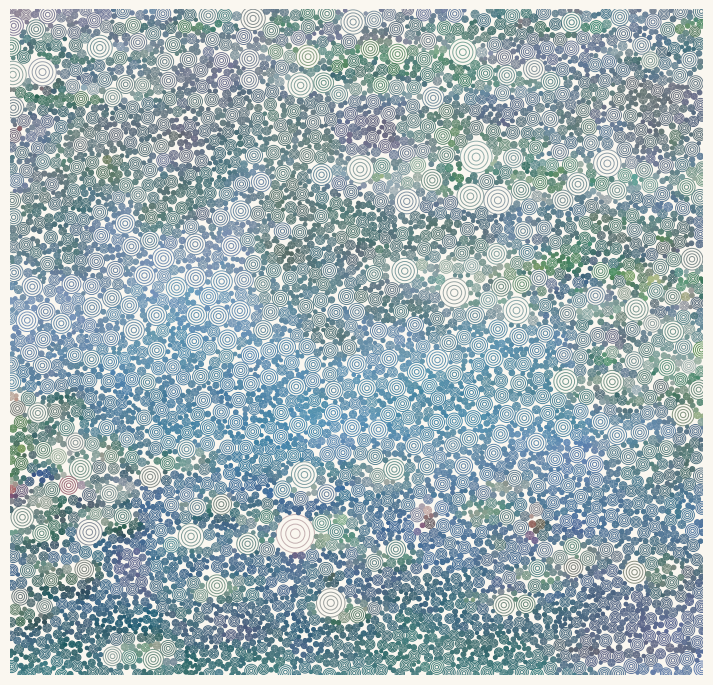

In [11]:
# concentric rings: the packed pond as a field of nested outlines
art_rings = draw_pack(centers, radii, circle_colors, scale_w, scale_h,
                      rings=4, figsize=9)
plt.show()

**Look and compare.** Fill and rings carry the same geometry, but the fills read as mosaic while the rings read as *drawing*: the paper breathes through every circle, and the big lily-pad circles turn into little targets that pull the eye. Which serves the pond better? Which would survive being drawn in ink by a machine that cannot fill?

## Parameter studies

Four packs of the same blank square, same seed, different rules. The radius range sets the grain, `step` quantizes it, and the `tries` budget decides how far the negotiation is allowed to run.

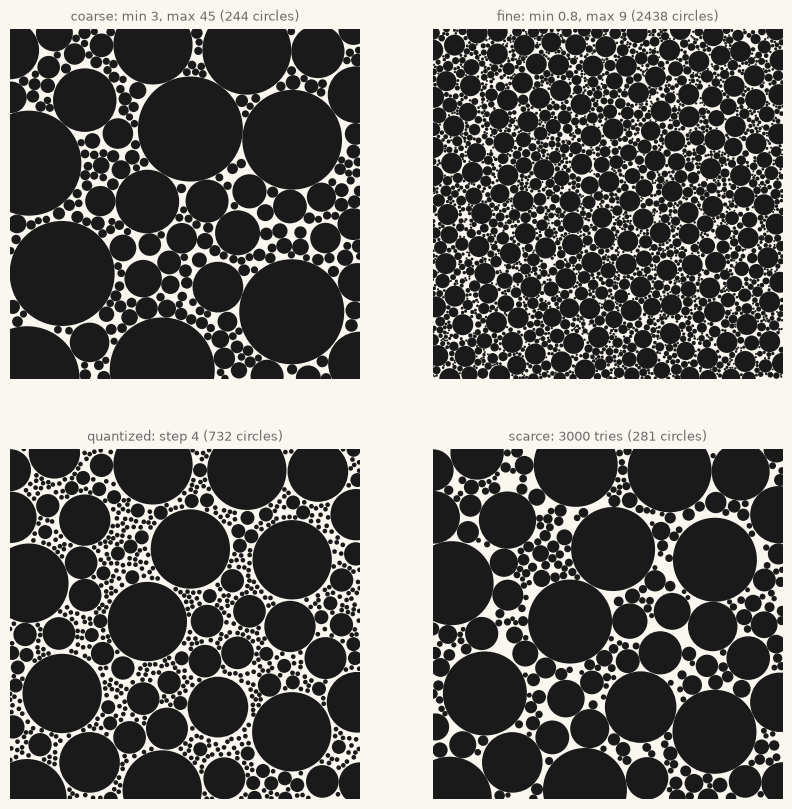

In [12]:
# four temperaments of the same square (same seed throughout)
studies = [
    ("coarse: min 3, max 45", dict(min_r=3, max_r=45)),
    ("fine: min 0.8, max 9", dict(min_r=0.8, max_r=9)),
    ("quantized: step 4", dict(min_r=2, max_r=36, step=4)),
    ("scarce: 3000 tries", dict(min_r=2, max_r=36, tries=3000)),
]
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for ax, (label, settings) in zip(axes.flat, studies):
    rng = np.random.default_rng(5)
    # **settings unpacks the dictionary into keyword arguments
    st_centers, st_radii = pack_growth(rng, 300, 300, **settings)
    draw_pack(st_centers, st_radii, "#1A1A1A", 300, 300, ax=ax)
    ax.set_title(f"{label} ({len(st_radii)} circles)", fontsize=9,
                 color="#6B6B6B")
plt.show()

**Look and compare.** Coarse is a pebble beach, fine is roe, the quantized pack snaps to a few sizes and starts to look *manufactured* (Hirst's grid winking from inside a packing), and the scarce pack is airy, all founders and no grain. Which one feels most like something grown? Which parameter is responsible: the range, the quantization, or the budget?

**Try it.** In the quantized study, change `step=4` to `step=10`: the pack collapses to just two or three sizes, and the manufactured look wins completely.

## Export your artwork

Pack your own: swap in another image from `assets/images/` (the Vermeer packs into a haunting darkness; the Hokusai's wave froths), or pack a blank canvas and color it from a palette. Adjust the radius range, the gamma of the budget, `rings`, the seed. Replace `yourname` and run; the print-quality PNG lands in `assets/outputs/`.

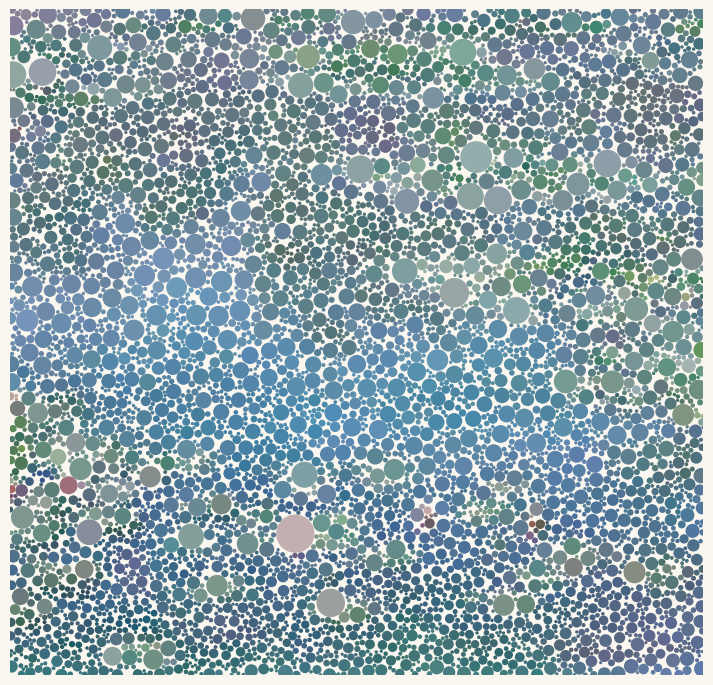

saved: assets/outputs/ch18_yourname.png


In [13]:
# save YOUR artwork: adjust the pack and its dress, replace 'yourname'
my_artwork = draw_pack(centers, radii, circle_colors, scale_w, scale_h, figsize=9)
plt.show()
saved_path = save_artwork(my_artwork, "yourname", chapter=18)

## Exercises

**(a) Parameter exploration: three grains.** Pack the blank 400-square three times with the same seed and the radius pairs `(0.6, 6)`, `(1.5, 18)` and `(4, 60)`. Describe each in chapter 15's stippling vocabulary: where does the ink budget go, which surface is fine grain and which coarse, which of the three feels calm? Then find the pair at which the pack stops feeling grown and starts feeling like polka dots, and defend your boundary in one sentence.

**(b) Code modification: pack inside a silhouette.** Restrict the packing to a *mask*: load the Vermeer in grayscale, threshold its darkness into a True/False silhouette, and write a masked variant of `pack_growth` in which proposals landing outside the mask are refused (a fresh copy is cleaner than editing the original). Ink on paper, no colors needed. With the threshold on *darkness*, the territory is the dark ground and the girl emerges as untouched paper: a portrait in negative, drawn entirely by refusal. (When you reach chapter 20, its frost-inside-a-figure exercise is this one's sibling: same move, different growth.)

<details><summary>Solution</summary>

```python
vermeer = Image.open("../assets/images/vermeer_pearl_earring.jpg")
v_w = 360
v_h = int(vermeer.height * v_w / vermeer.width)
v_gray = np.asarray(vermeer.convert("L").resize((v_w, v_h))) / 255
silhouette = (1 - v_gray) > 0.55        # True where the painting is dark

def pack_in_mask(rng, allowed, min_r=1.0, max_r=14, tries=40000):
    height, width = allowed.shape
    centers, radii = [], []
    for proposal in range(tries):
        x, y = rng.uniform(0, width), rng.uniform(0, height)
        if not allowed[int(y), int(x)]:  # outside the silhouette: refuse
            continue
        room = max_r
        if centers:
            gaps = (np.linalg.norm(np.array(centers) - [x, y], axis=1)
                    - np.array(radii))
            room = min(max_r, gaps.min())
        if room < min_r:
            continue
        centers.append([x, y])
        radii.append(room)
    return np.array(centers), np.array(radii)

rng = np.random.default_rng(2)
m_centers, m_radii = pack_in_mask(rng, silhouette)
fig = draw_pack(m_centers, m_radii, "#1A1A1A", v_w, v_h, figsize=7)
plt.show()
```

Only the *center* is tested against the mask, so border circles lean out over the silhouette's edge and soften it, which suits the subject. Pack `~silhouette` (the mask inverted) instead and the logic flips: now the girl herself fills with grain and the room goes blank. For a strict fit, refuse a proposal unless the mask is also True at the four compass points `(x - room, y)`, `(x + room, y)`, `(x, y - room)`, `(x, y + room)` (clipped to the canvas so the probes stay in bounds).
</details>

**(c) Creative challenge: one level deeper.** Two directions, pick one. *Gasket-flavored*: choose the largest circle in a finished pack, treat its interior as a fresh canvas, and run `pack_growth` again inside it (refuse proposals farther than its radius from its center), so one founder carries a whole second generation. *Or the motif*: instead of a fill, draw your own small motif at every circle's center, scaled by its radius: a chapter 3 star, a spiral, a letter of your name. Either way the packing is no longer the artwork; it has become the *composition* underneath one, which is how the technique earns its living in the wild. Name the piece and bring it to the gallery.

## Further reading

- Yayoi Kusama, *Infinity Net: The Autobiography of Yayoi Kusama* (trans. Ralph McCarthy, Tate Publishing, 2011): obsessive space-filling from the inside, by the person who lives there.
- Helmut Friedel and Annegret Hoberg, *Kandinsky: Absolute. Abstract.* (Prestel, 2008): the retrospective catalogue from the Lenbachhaus, home of the concentric-rings color study.
- John Shier and Paul Bourke, "An Algorithm for Random Fractal Filling of Space", *Computer Graphics Forum* 32.8 (2013), with the picture-rich companion page at [paulbourke.net/fractals/randomtile](https://paulbourke.net/fractals/randomtile/): what happens to packing when the sizes follow a strict power law.
- Tyler Hobbs, "A Randomized Approach to Circle Packing" (2016, free on tylerxhobbs.com): a leading generative artist's working notes on exactly today's algorithm, trade-offs included.

## References

- <span id="ref-coxeter1968"></span>Coxeter, H. S. M. (1968). The problem of Apollonius. *Canadian Mathematical Bulletin*, 11(1), 1–17. [doi:10.4153/CMB-1968-001-7](https://doi.org/10.4153/CMB-1968-001-7). Retells the whole lineage: Apollonius's lost treatise, Descartes's 1643 letters to Elisabeth, Soddy's poem.
- <span id="ref-hirst"></span>Damien Hirst studio. Spot paintings: series text. [damienhirst.com](https://www.damienhirst.com/texts1/series/spots). The Pharmaceutical series and its rules, in the studio's own words.
- <span id="ref-heath1921"></span>Heath, T. L. (1921). *A History of Greek Mathematics*, vol. II. Clarendon Press. Apollonius's dates and the lost treatise on tangencies.
- <span id="ref-hobbs2016"></span>Hobbs, T. (2016). A Randomized Approach to Circle Packing. [tylerxhobbs.com](https://www.tylerxhobbs.com/words/a-randomized-approach-to-circle-packing). A leading generative artist's working notes on exactly this chapter's algorithm.
- <span id="ref-kusama2011"></span>Kusama, Y. (2011). *Infinity Net: The Autobiography of Yayoi Kusama* (trans. R. McCarthy). Tate Publishing. First published in Japanese, 2002; the *Infinity Nets* and "self-obliteration" from the inside.
- <span id="ref-soddy1936"></span>Soddy, F. (1936). The Kiss Precise. *Nature*, 137, 1021. [doi:10.1038/1371021a0](https://doi.org/10.1038/1371021a0). The theorem, in verse.
- <span id="ref-lenbachhaus"></span>Städtische Galerie im Lenbachhaus und Kunstbau, München. *Farbstudie – Quadrate mit konzentrischen Ringen*, Wassily Kandinsky, 1913. [Collection entry](https://www.lenbachhaus.de/en/digital/collection-online/detail/farbstudie-quadrate-mit-konzentrischen-ringen-30017624).

---
### Appendix: regenerate the showpiece

This last cell (re)creates the image shown at the top of the notebook: ninety thousand proposals, over seven thousand circles, well under a minute of negotiation. It runs automatically with *Restart & Run All*. At home, raise `tries` to 150000 and lower `min_r` to 0.8 for an even silkier grain.

7296 circles


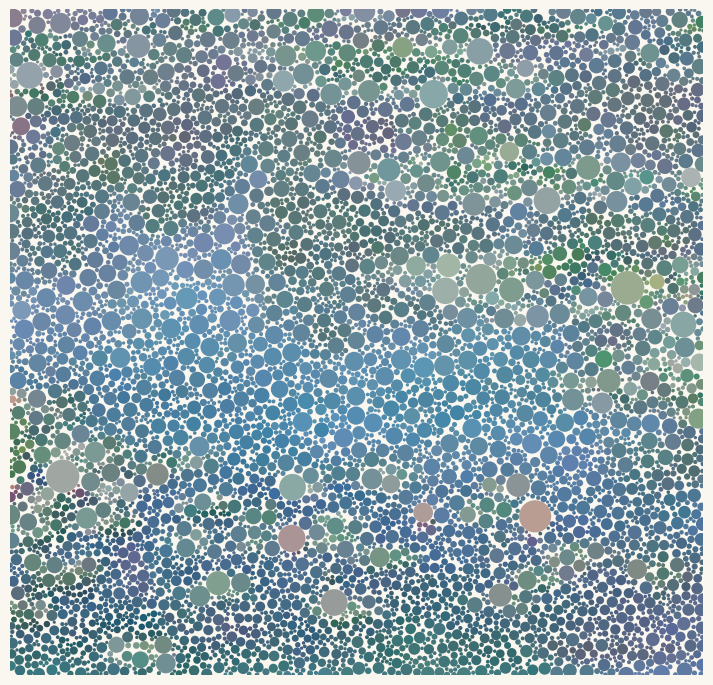

saved: assets/outputs/ch18_showpiece.png


In [14]:
# regenerate this chapter's showpiece: the packed-circle Monet
rng_show = np.random.default_rng(1906)
show_centers, show_radii = pack_growth(rng_show, scale_w, scale_h, min_r=1.1,
                                       max_r=22, tries=90000, cap_map=cap_map)
show_colors = smooth_color[show_centers[:, 1].astype(int),
                           show_centers[:, 0].astype(int)]
print(f"{len(show_radii)} circles")
showpiece = draw_pack(show_centers, show_radii, show_colors, scale_w, scale_h,
                      figsize=9)
plt.show()
saved_path = save_artwork(showpiece, "showpiece", chapter=18)